In [71]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

data = yf.download('EQNR.OL', start='2023-01-01', end='2024-01-01')
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,EQNR.OL,EQNR.OL,EQNR.OL,EQNR.OL,EQNR.OL
Date,,,,,
2023-01-02,280.908569,282.418209,278.842792,280.392125,1601510
2023-01-03,265.216461,283.133286,264.819193,281.981198,4536272
2023-01-04,252.265518,261.243777,251.868250,261.243777,6346931
2023-01-05,253.934006,256.238158,252.186015,255.364163,6637221
2023-01-06,255.483429,259.178046,251.073757,258.224592,5956488


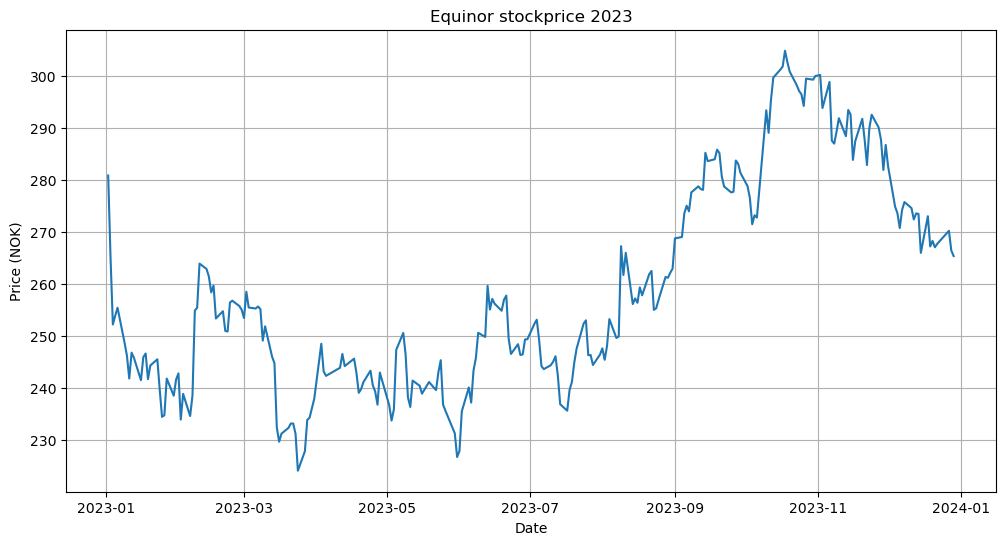

In [72]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'])
plt.title('Equinor stockprice 2023')
plt.xlabel('Date')
plt.ylabel('Price (NOK)')
plt.grid(True)
plt.show()

In [73]:
data['Daily_Return'] = data['Close'].pct_change()
data['Daily_Return'].head(10)

Date
2023-01-02         NaN
2023-01-03   -0.055862
2023-01-04   -0.048832
2023-01-05    0.006614
2023-01-06    0.006102
2023-01-09   -0.026353
2023-01-10   -0.009929
2023-01-11   -0.017956
2023-01-12    0.020590
2023-01-13   -0.004035
Name: Daily_Return, dtype: float64

[*********************100%***********************]  1 of 1 completed


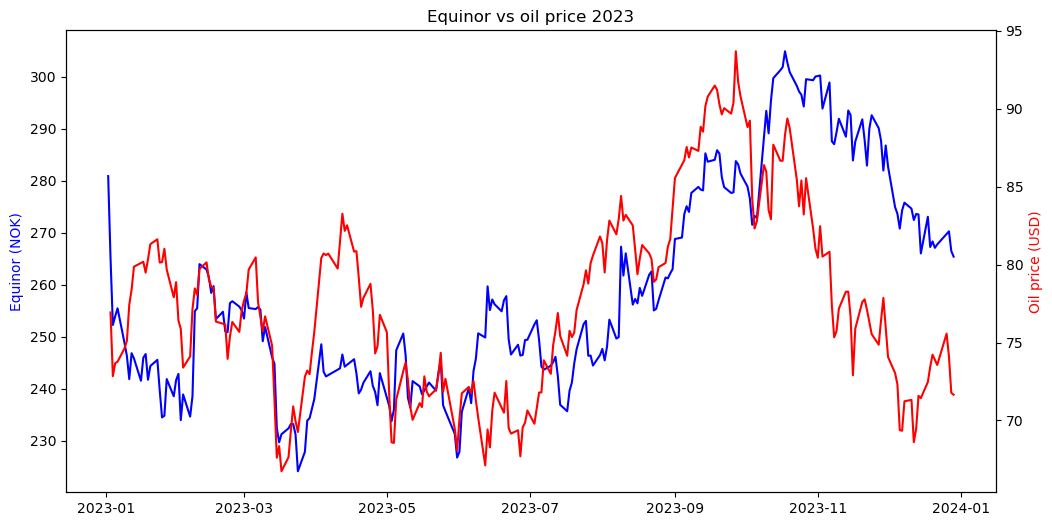

In [74]:
# Oil price for the same period
oil = yf.download('CL=F', start='2023-01-01', end='2024-01-01')

# Plot begge
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(data.index, data['Close'], 'b-', label='Equinor')
ax1.set_ylabel('Equinor (NOK)', color='b')

ax2 = ax1.twinx()
ax2.plot(oil.index, oil['Close'], 'r-', label='Oljepris (USD)')
ax2.set_ylabel('Oil price (USD)', color='r')

plt.title('Equinor vs oil price 2023')
plt.show()

In [75]:
# Convert to Series and calculate
equinor_close = data['Close'].squeeze()
oil_close = oil['Close'].squeeze()

correlation = equinor_close.corr(oil_close)
print(f"Correlation: {correlation:.3f}")


Correlation: 0.546


In [76]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Create DataFrame with both and remove mismatches
df = pd.DataFrame({
    'Equinor': data['Close'].squeeze(),
    'Oil': oil['Close'].squeeze()
})

# Remove all rows with NaN
df = df.dropna()

# Now we have matching data
X = df['Oil'].values.reshape(-1, 1)  # Oil price (2D array)
y = df['Equinor'].values  # Equinor

# Build the model
model = LinearRegression()
model.fit(X, y)

# Results
print(f"β₀ (Intercept): {model.intercept_:.2f} NOK")
print(f"β₁ (Slope): {model.coef_[0]:.2f} NOK per USD oil price")
print(f"R²: {model.score(X, y):.3f}")


β₀ (Intercept): 117.58 NOK
β₁ (Slope): 1.82 NOK per USD oil price
R²: 0.298


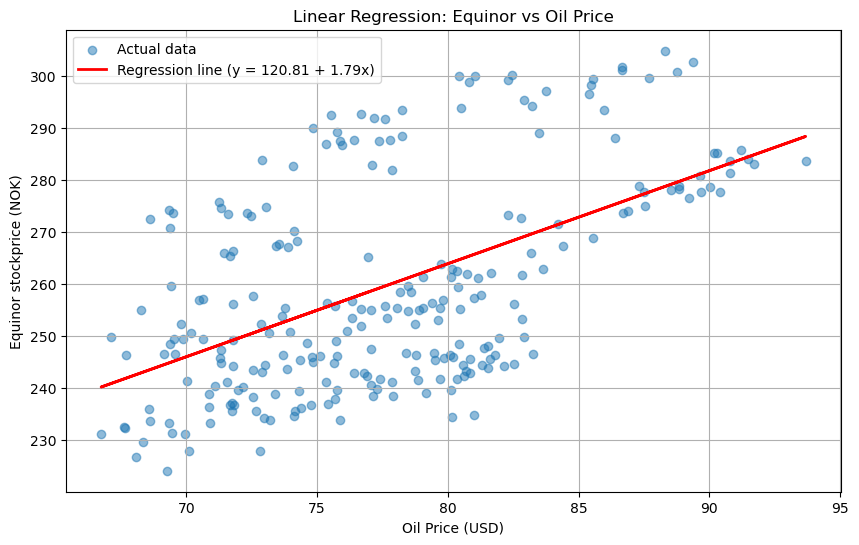

In [86]:
# Visualize the regression line
plt.figure(figsize=(10,6))
plt.scatter(df['Oil'], df['Equinor'], alpha=0.5, label='Actual data')

# Lag prediksjoner
predicted = model.predict(X)
plt.plot(df['Oil'], predicted, color='red', linewidth=2, label=f'Regression line (y = {model.intercept_:.2f} + {model.coef_[0]:.2f}x)')

plt.xlabel('Oil Price (USD)')
plt.ylabel('Equinor stockprice (NOK)')
plt.title('Linear Regression: Equinor vs Oil Price')
plt.legend()
plt.grid(True)
plt.show()


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

print(f"R² on training data: {r2_train:.3f}")
print(f"R² on test data: {r2_test:.3f}")


R² on training data: 0.294
R² on test data: 0.308


In [79]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge = RidgeCV(cv=5)
ridge.fit(X_train, y_train)

lasso = LassoCV(cv=5)
lasso.fit(X_train, y_train)

print(f"Ridge R² on test data: {ridge.score(X_test, y_test):.3f}")
print(f"Lasso R² on test data: {lasso.score(X_test, y_test):.3f}")
print(f"Ordinary regression R² on test data: {r2_test:.3f}")


Ridge R² on test data: 0.308
Lasso R² on test data: 0.307
Ordinary regression R² on test data: 0.308


In [80]:
print(f"Lasso coefficients: {lasso.coef_}")

Lasso coefficients: [1.74497508]


In [81]:
df['Target'] = (df['Equinor'].shift(-1) > df['Equinor']).astype(int)
df = df.dropna()
print(df[['Equinor', 'Target']].head(10))

               Equinor  Target
Date                          
2023-01-03  265.216461       0
2023-01-04  252.265518       1
2023-01-05  253.934006       1
2023-01-06  255.483429       0
2023-01-09  248.750671       0
2023-01-10  246.280762       0
2023-01-11  241.858658       1
2023-01-12  246.838455       0
2023-01-13  245.842545       1
2023-01-17  245.962021       1


In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_clf = df[['Oil']]
y_clf = df['Target']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train_clf, y_train_clf)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_clf, y_train_clf)

print(f"Logistic Regression accuracy: {accuracy_score(y_test_clf, log_reg.predict(X_test_clf)):.3f}")
print(f"Random Forest accuracy: {accuracy_score(y_test_clf, rf.predict(X_test_clf)):.3f}")

Logistic Regression accuracy: 0.490
Random Forest accuracy: 0.490


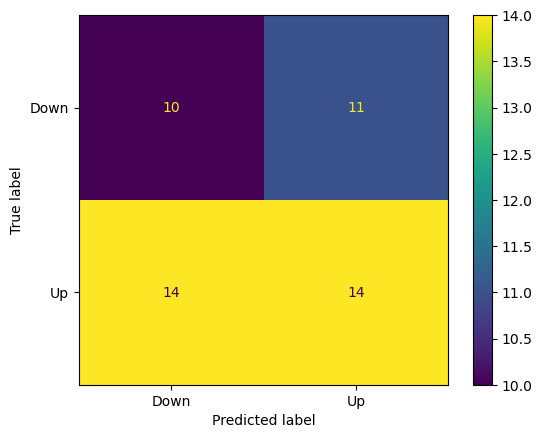

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_clf, rf.predict(X_test_clf))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot()

In [84]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_clf, y_clf, cv=5)

print(f"CV scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.3f}")
print(f"Standard deviation: {cv_scores.std():.3f}")


CV scores: [0.59183673 0.55102041 0.53061224 0.42857143 0.5625    ]
Mean: 0.533
Standard deviation: 0.056


In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(X_train_clf, y_train_clf)
print(f"Logistic Regression with scaling: {pipeline.score(X_test_clf, y_test_clf):.3f}")

Logistic Regression med scaling: 0.490
